# **Predicting Real Estate Properties Prices using Machine Learning by Emiliano Pedraza, Physics Engineer**

The following document goes through the process of accesing, reading, formatting, inspecting, exploring and analysing data regarding real estate properties in the United States with Python. The dataset used is **USA Real Estate Dataset - Real Estate listings (2.2M+) from Kaggle (https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset)**

## Installation of kagglehub to obtain the dataset to be used.

In [142]:
!pip install kagglehub[pandas-datasets]

## All libraries


In [143]:
#Standard Libraries & Data Handling
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

#Handling of warnings
import warnings
warnings.filterwarnings('ignore')

In [144]:
pd.set_option('display.float_format', '{:,.2f}'.format)

## Constructed functions

In [145]:
def corr_matrix(df):
  list_methods= ["pearson", "kendall", "spearman"]
  for i in list_methods:
    corr_matrix = df.corr(method= i)
    plt.figure(figsize=(5, 4))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
    plt.title(f"Correlation Heatmap {capitalize(i)}")
    plt.show()

## **Reading the data**

In [146]:
file_path = "realtor-data.zip.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ahmedshahriarsakib/usa-real-estate-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'usa-real-estate-dataset' dataset.


 Content
* realtor-data.csv (2,226,382 entries)
* brokered by (categorically encoded agency/broker)
* status (Housing status - a. ready for sale or b. ready to build)
* price (Housing price, it is either the current listing price or recently sold * price if the house is sold recently)
* bed (# of beds)
* bath (# of bathrooms)
* acre_lot (Property / Land size in acres)
* street (categorically encoded street address)
* city (city name)
* state (state name)
* zip_code (postal code of the area)
* house_size (house area/size/living space in square feet)
* prev_sold_date (Previously sold date)

NB:

* brokered by and street addresses were categorically encoded due to data privacy policy
* acre_lot means the total land area, and house_size denotes the living space/building area



In [147]:
df_data=df.copy()

Given the massive size of the dataset, we will choose a sample from it so to better manipulate the data without awaiting for long computing times.

In [148]:
df_sample= df_data.sample(frac=0.01)

Visualization of the raw data

In [149]:
df_sample.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
1897101,"57,502.00",sold,"110,000.00",2.00,1.00,0.18,"1,821,235.00",Farmington,Arkansas,"72,730.00","1,108.00",2022-03-31
905709,"83,171.00",for_sale,"259,900.00",3.00,2.00,0.28,"1,214,134.00",Pevely,Missouri,"63,070.00","1,269.00",NaN
1161879,"98,255.00",for_sale,"60,000.00",NaN,NaN,0.33,"1,882,963.00",Montrose,Colorado,"81,401.00",NaN,NaN
1094887,"109,987.00",for_sale,"189,000.00",NaN,NaN,0.54,"728,058.00",San Antonio,Texas,"78,255.00",NaN,NaN
846736,"24,231.00",for_sale,"295,000.00",NaN,NaN,2.54,"2,823.00",Laurel,Montana,"59,044.00",NaN,NaN


### **Data Preparation**

### Filtering and dropping of non-relevant information

In [150]:
us_states_list = ["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"]
df_filtered = df_sample[df_sample["state"].isin(us_states_list)].copy()
df_filtered = df_filtered.dropna(subset=["price"])
df_filtered["status"] = np.where(df_filtered["status"] == "for_sale", 1, 0)

### Exploratory Data Analysis

In [151]:
from numpy._core.defchararray import capitalize
numerical_cols = df_filtered.select_dtypes(include=[np.number]).columns

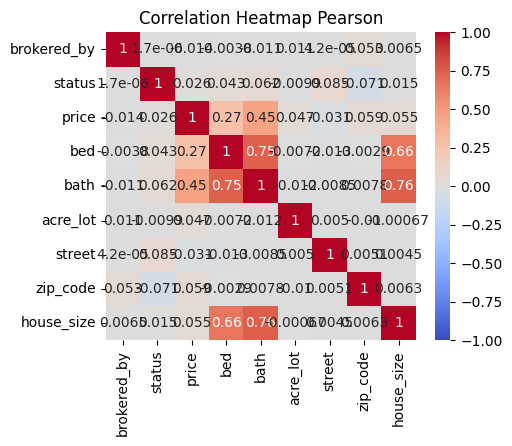

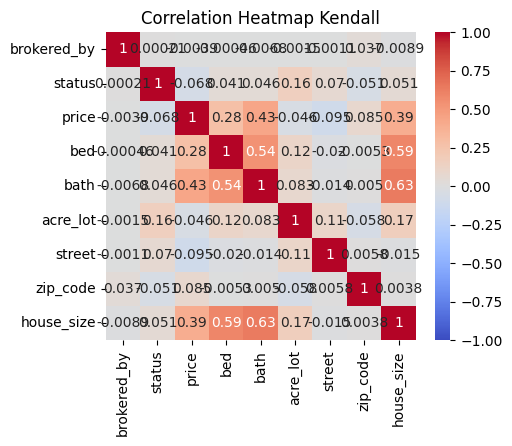

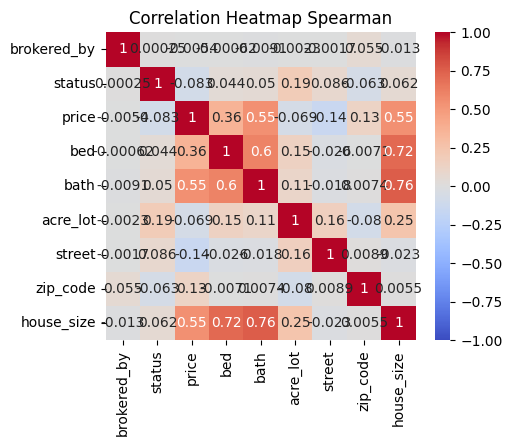

In [152]:
corr_matrix(df_filtered[numerical_cols])

### Train/test split
After having observed the heatmap, the fields bed, bath and house_size are selected as the most relevant ones to observe in regards to price. State is added, knowing its importance in the real world.

In [153]:
features = ["bed", "bath", "house_size", "state"]
X = df_filtered[features]
y = df_filtered["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (15488, 4)
Testing data shape: (6639, 4)


### Removing outliers

In [154]:
z_scores = np.abs(stats.zscore(y_train))

outlier_mask = z_scores < 2

X_train = X_train[outlier_mask]
y_train = y_train[outlier_mask]

print(f"Training data shape: {X_train.shape}")

Training data shape: (15197, 4)


### Cleaning and formatting

In [155]:
numeric_features = ["bed", "bath", "house_size"]
categorical_features = ["state"]

numeric_transformer = Pipeline(steps=[("imputer", KNNImputer(n_neighbors=2)), ("scaler", StandardScaler()), ("poly", PolynomialFeatures(include_bias=False))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])

### Gridsearch Cross-Validation, Modeling
Setting up the full pipeline

In [156]:
pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", Ridge())])

Hyperparameters to test and setting up the gridsearch

In [157]:
param_grid = {"preprocessor__num__poly__degree": [1, 2, 3], "model__alpha": [0.1, 1.0, 10.0]}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation R-square: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best parameters: {'model__alpha': 1.0, 'preprocessor__num__poly__degree': 1}
Best cross-validation R-square: 0.3252


### Predicting of price data

In [158]:
best_model = grid_search.best_estimator_

Prediction on the test data and comparison with the actual price data


In [159]:
y_pred = best_model.predict(X_test)

mse_final = mean_squared_error(y_test, y_pred)
r2_final = r2_score(y_test, y_pred)

print(f"Test Set MSE: {mse_final}")
print(f"Test Set R-square: {r2_final}")

Test Set MSE: 5445903511130.183
Test Set R-square: -1.7846346039485836


### Visualization of the data

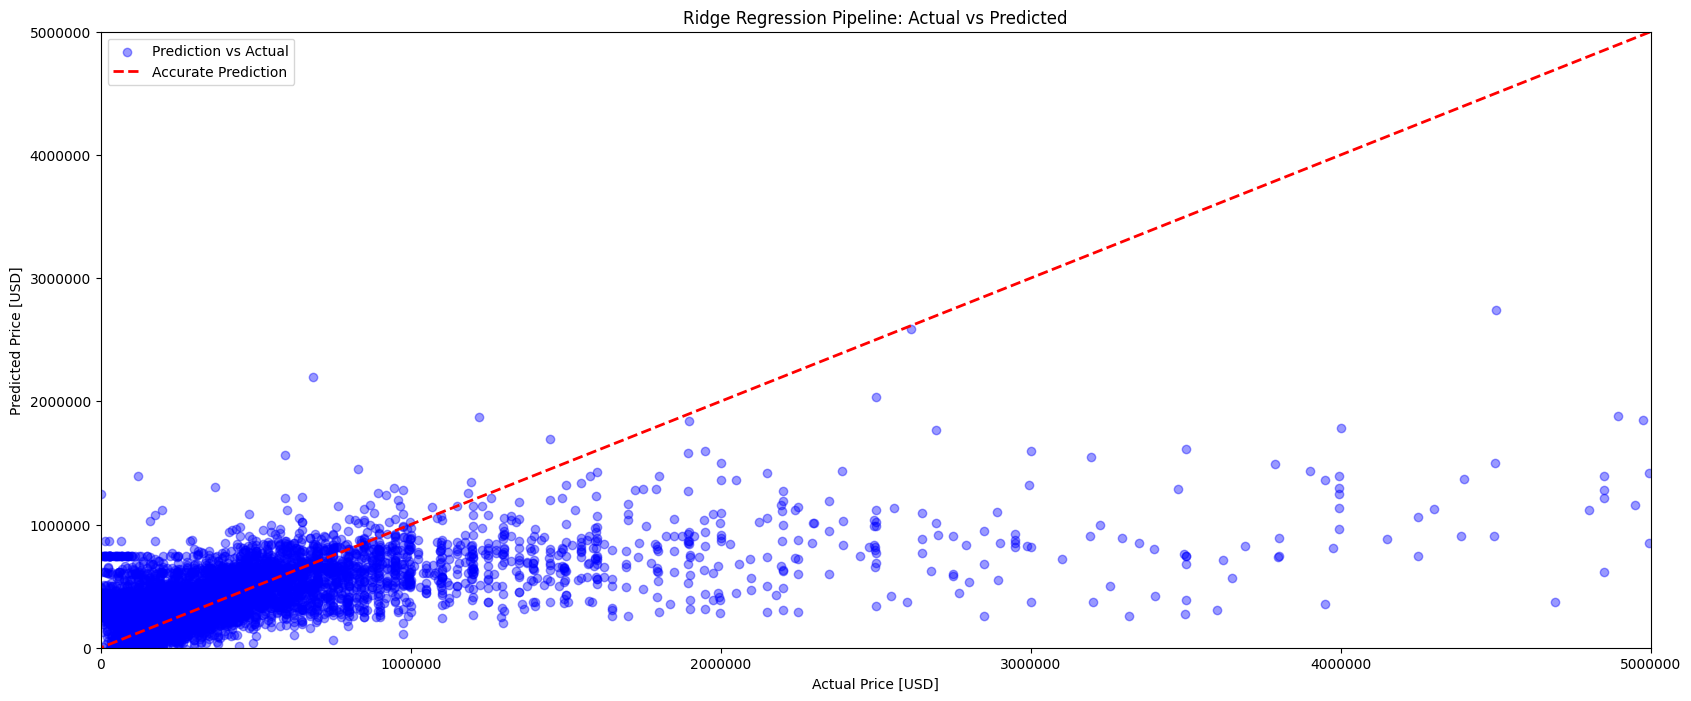

In [160]:
plt.figure(figsize=(20, 8))
plt.scatter(y_test, y_pred, color="blue", alpha=0.4, label="Prediction vs Actual")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, linestyle="--", label="Accurate Prediction")

plt.ylim(0, 5000000)
plt.xlim(0, 5000000)
plt.xlabel("Actual Price [USD]")
plt.ylabel("Predicted Price [USD]")
plt.title("Ridge Regression Pipeline: Actual vs Predicted")
plt.legend()
plt.ticklabel_format(style="plain", axis="both")
plt.show()

Comparison between predicted and real data

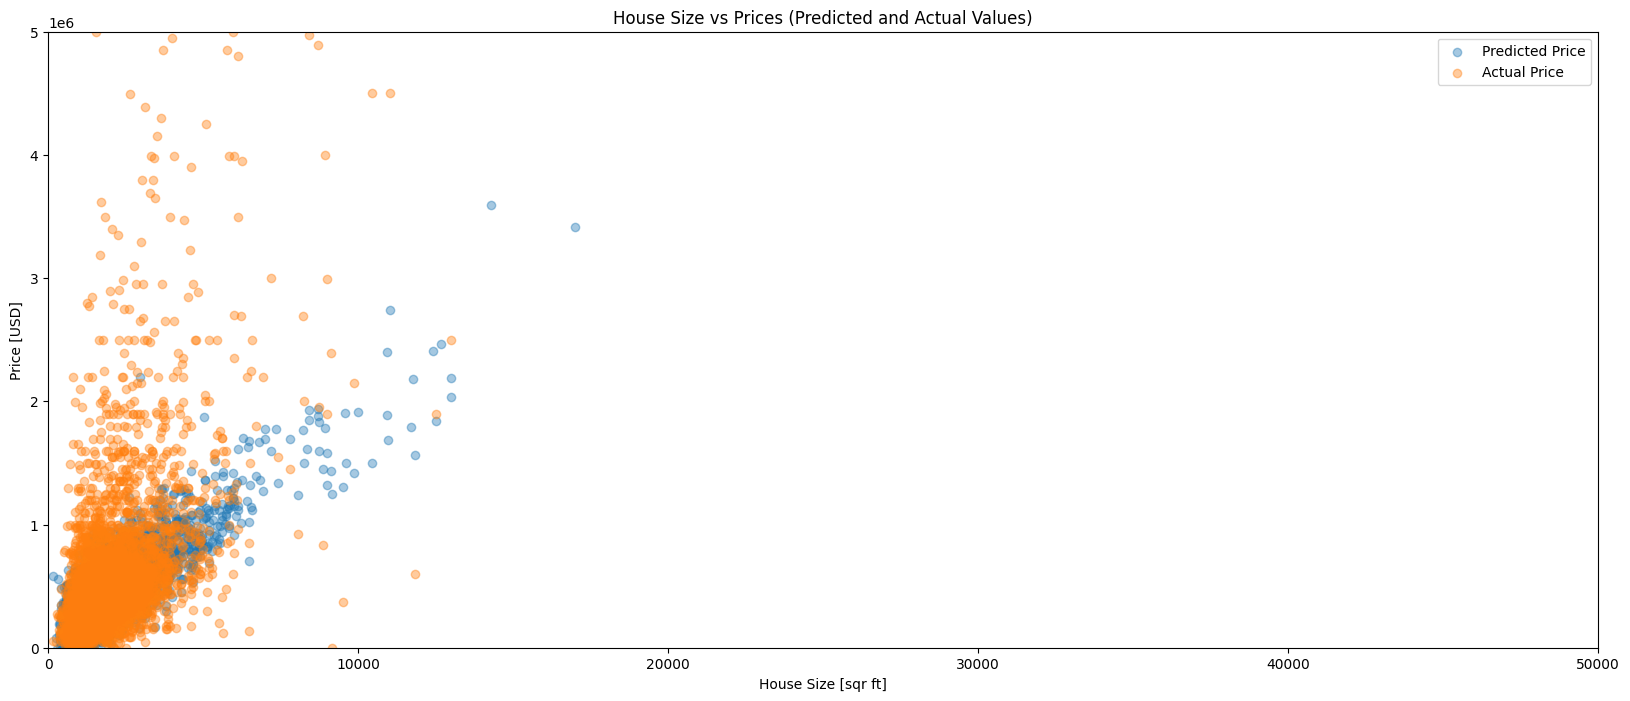

In [161]:
plt.figure(figsize=(20, 8))
plt.scatter(X_test["house_size"], y_pred, alpha=0.4, label="Predicted Price")
plt.scatter(X_test["house_size"], y_test, alpha=0.4, label="Actual Price")
plt.xlabel("House Size [sqr ft]")
plt.ylabel("Price [USD]")
plt.title("House Size vs Prices (Predicted and Actual Values)")
plt.ylim(0, 5000000)
plt.xlim(0, 50000)
plt.legend()
plt.show()

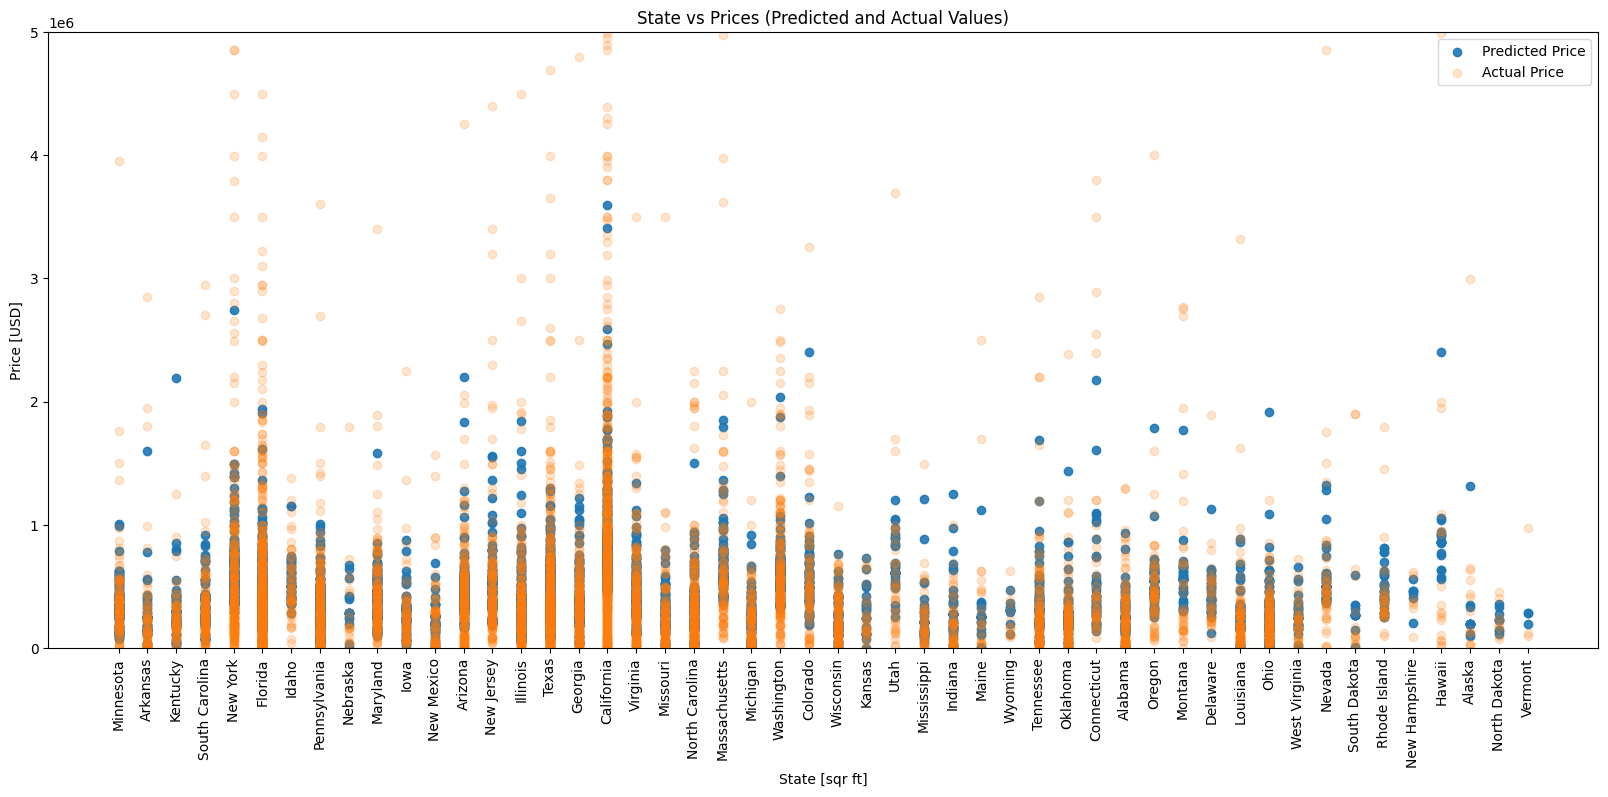

In [162]:
plt.figure(figsize=(20, 8))
plt.scatter(X_test["state"], y_pred, alpha=0.9, label="Predicted Price")
plt.scatter(X_test["state"], y_test, alpha=0.2, label="Actual Price")
plt.xlabel("State [sqr ft]")
plt.xticks(rotation=90)
plt.ylabel("Price [USD]")
plt.title("State vs Prices (Predicted and Actual Values)")
plt.ylim(0, 5000000)
plt.legend()
plt.show()

### **Conclusion and summary**

The model achieved an inaccurate R-squared value on the test set, indicating that a small percentage of prices is explained by the features used (beds, baths, house size, and state). On the other hand, the Mean Squared Error (MSE) remains very high, and the visualization shows that while the model captures a general trend, there is significant variance in actual prices that the current features do not fully explain.

The scatter plot of **House Size vs. Price** reveals a positive correlation, though the model fails to accurately pin-point and predict the exact behaviour of the actual data.
Significant outliers in actual prices are visible, most likely consequence of factors not included in the dataset and not taken into account in the model (e.g., neighborhood quality, specific amenities, closeness to schools or economic centers, etc) and which play a massive role in real estate valuation.

The current dataset fails to consider localized features like city-level economic data, property age, and other particular features from listing descriptions that most likely impact real estate trends. Future models would benefit from such information in order to improve predictive accuracy. Nonetheless, some actions could be taken to slightly improve the model using the existing data, for example, running the whole process but filtering for only one specific state, as is shown now.

For the top 5 richest states:

California
Fitting 5 folds for each of 9 candidates, totalling 45 fits


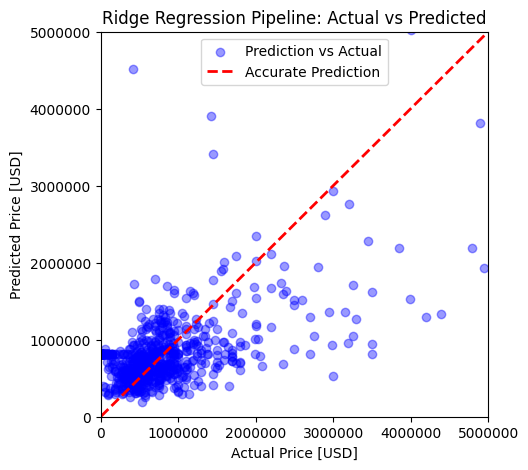

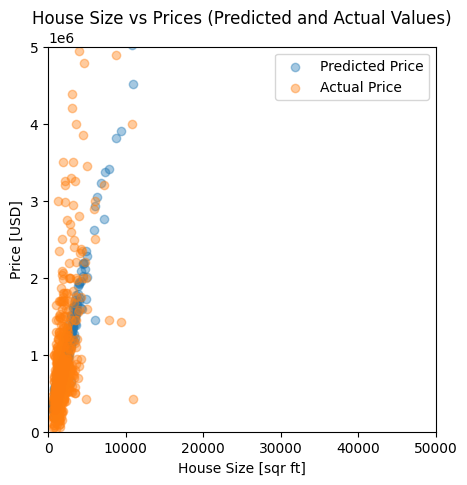

Test Set MSE: 5811694500121.529
Test Set R-square: 0.16077123479873956 

Massachusetts
Fitting 5 folds for each of 9 candidates, totalling 45 fits


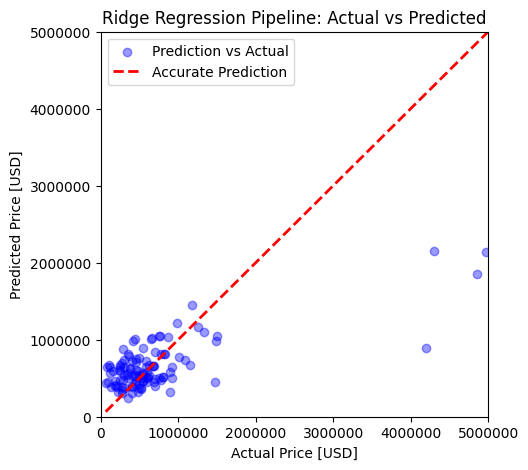

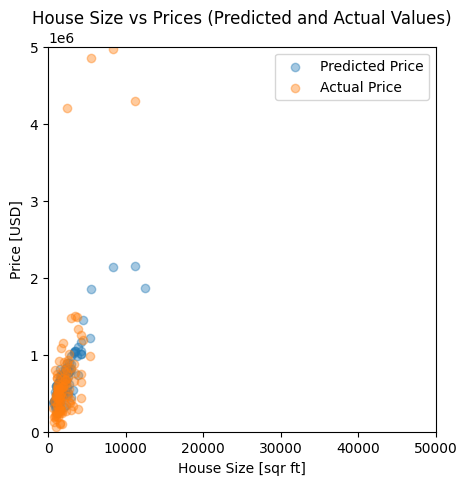

Test Set MSE: 569627434323.7529
Test Set R-square: 0.409116084887185 

Washington
Fitting 5 folds for each of 9 candidates, totalling 45 fits


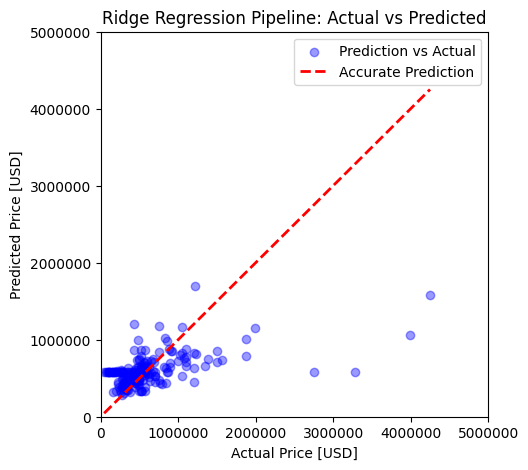

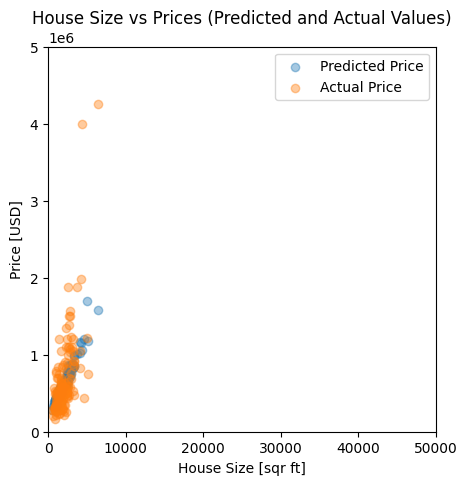

Test Set MSE: 227976634271.53824
Test Set R-square: 0.2655397030566051 

New York
Fitting 5 folds for each of 9 candidates, totalling 45 fits


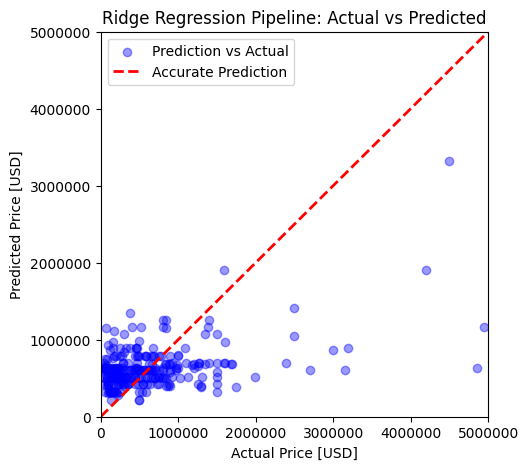

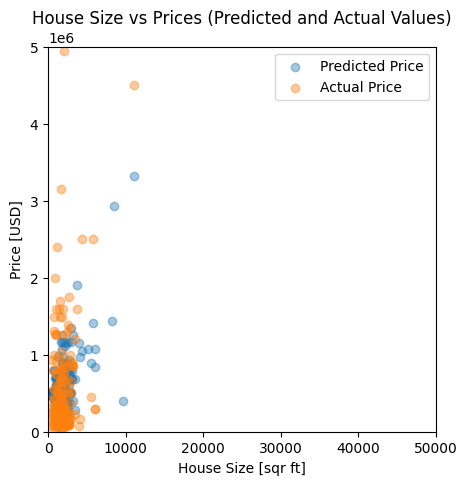

Test Set MSE: 5540157215327.656
Test Set R-square: 0.05532198348694439 

Hawaii
Fitting 5 folds for each of 9 candidates, totalling 45 fits


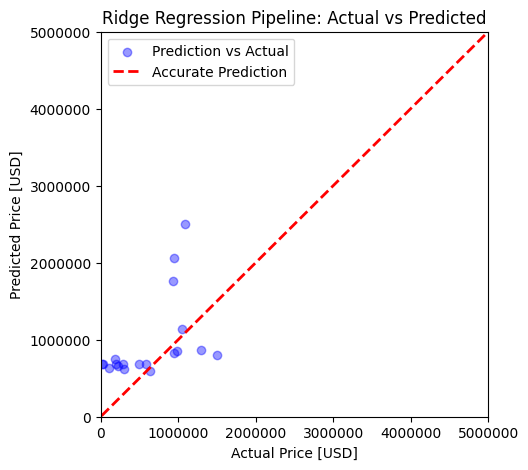

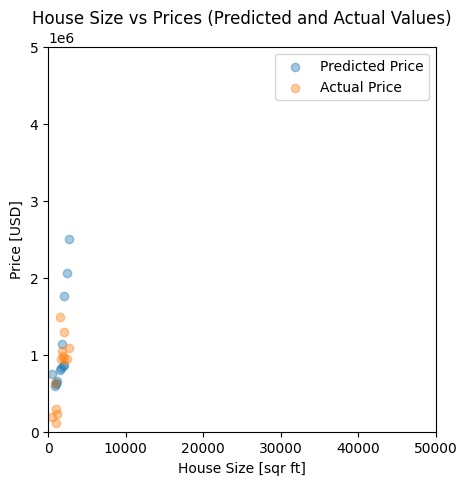

Test Set MSE: 7725800708292.727
Test Set R-square: 0.2016477421488594 



In [163]:
for i in ["California", "Massachusetts", "Washington", "New York", "Hawaii"]:
  print(i)
  us_states_list=[i]
  df_filtered = df_sample[df_sample["state"].isin(us_states_list)].copy()
  df_filtered = df_filtered.dropna(subset=["price"])
  df_filtered["status"] = np.where(df_filtered["status"] == "for_sale", 1, 0)

  from numpy._core.defchararray import capitalize
  numerical_cols = df_filtered.select_dtypes(include=[np.number]).columns

  features = ["bed", "bath", "house_size", "state"]
  X = df_filtered[features]
  y = df_filtered["price"]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

  z_scores = np.abs(stats.zscore(y_train))

  outlier_mask = z_scores < 2

  X_train = X_train[outlier_mask]
  y_train = y_train[outlier_mask]

  numeric_features = ["bed", "bath", "house_size"]
  categorical_features = ["state"]

  numeric_transformer = Pipeline(steps=[("imputer", KNNImputer(n_neighbors=2)), ("scaler", StandardScaler()), ("poly", PolynomialFeatures(include_bias=False))])
  categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
  preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])
  pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", Ridge())])

  param_grid = {"preprocessor__num__poly__degree": [1, 2, 3], "model__alpha": [0.1, 1.0, 10.0]}

  kfold = KFold(n_splits=5, shuffle=True, random_state=42)
  grid_search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', verbose=1, n_jobs=-1)

  grid_search.fit(X_train, y_train)

  best_model = grid_search.best_estimator_

  y_pred = best_model.predict(X_test)

  mse_final = mean_squared_error(y_test, y_pred)
  r2_final = r2_score(y_test, y_pred)

  plt.figure(figsize=(5, 5))
  plt.scatter(y_test, y_pred, color="blue", alpha=0.4, label="Prediction vs Actual")

  min_val = min(y_test.min(), y_pred.min())
  max_val = max(y_test.max(), y_pred.max())
  plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, linestyle="--", label="Accurate Prediction")

  plt.ylim(0, 5000000)
  plt.xlim(0, 5000000)
  plt.xlabel("Actual Price [USD]")
  plt.ylabel("Predicted Price [USD]")
  plt.title("Ridge Regression Pipeline: Actual vs Predicted")
  plt.legend()
  plt.ticklabel_format(style="plain", axis="both")
  plt.show()

  plt.figure(figsize=(5, 5))
  plt.scatter(X_test["house_size"], y_pred, alpha=0.4, label="Predicted Price")
  plt.scatter(X_test["house_size"], y_test, alpha=0.4, label="Actual Price")
  plt.xlabel("House Size [sqr ft]")
  plt.ylabel("Price [USD]")
  plt.title("House Size vs Prices (Predicted and Actual Values)")
  plt.ylim(0, 5000000)
  plt.xlim(0, 50000)
  plt.legend()
  plt.show()

  print(f"Test Set MSE: {mse_final}")
  print(f"Test Set R-square: {r2_final} \n")

These specific iterations focusing on one state at a time show slightly better results, but still not satisfactory enough. Once more, it is clear that further and more specific information is necessary to wholesomely tackle the problem at hand.